In [1]:
import os
import sys
sys.path.append(os.path.expanduser("~"))
from camel_dataloader import get_astro_data,get_astro_data_2D_from_3D
from utils import draw_figure,compute_pk, plot_residual
import comet_ml
import torch
from torch import nn
from torch.nn.functional import mse_loss, l1_loss
from torch import autograd, Tensor
from lightning.pytorch import LightningModule, Trainer, seed_everything
from lightning.pytorch.loggers import CometLogger
from lightning.pytorch.callbacks import LearningRateMonitor, ModelCheckpoint
from typing import Optional, Tuple
from torch.special import expm1
from tqdm import trange
from torch.distributions.normal import Normal
import numpy as np
import matplotlib.pyplot as plt

torch.set_float32_matmul_precision('highest')
device = torch.device("cuda") if torch.cuda.is_available() else "mps"
print(device)

cuda


In [2]:
seed_everything(7, workers=True)
cropsize = 256
batch_size = 12
num_workers = 8
   
dataset = 'Astrid'
learning_rate = 1e-3 #1e-4


[rank: 0] Seed set to 7


In [10]:
class trainCNN(LightningModule):
    def __init__(
        self,
        model,
        learning_rate: float = 3.0e-4,
        weight_decay: float = 1.0e-2,
        n_sampling_steps: int = 250, 
        fourier_upweight_range=(3, 10), 
        fourier_weight=1e-5,
        draw_figure=None,
        plot_residual=None,
        dataset='illustris',
        **kwargs
    ):
        super().__init__()
        self.save_hyperparameters(ignore=["draw_figure","plot_residual"])
        
        self.model= model
        self.dataset=dataset
        print("suite:", self.dataset)
        self.draw_figure=draw_figure
        self.plot_residual=plot_residual
        self.fourier_upweight_range = fourier_upweight_range
        self.fourier_weight = fourier_weight
        
        if self.draw_figure is None:
            def draw_figure(args,**kwargs):
                fig=plt.figure(figsize=(5,5))
                return fig
            self.draw_figure=draw_figure

    def forward(self, cdm_map, params) -> Tensor:
        cdm_map = cdm_map
        params = params
        return self.model(cdm_map,params)

    def evaluate(self, batch: Tuple, stage: str = None) -> Tensor:

        cdm_map,params,true_map = batch
        cdm_map = cdm_map.to(device)
        params = params.to(device)
        true_map = true_map.to(device)
        mtot_pred = self(cdm_map,params).to(device)
        fourier_loss = self.fourier_loss(mtot_pred, true_map)
        # Log the individual loss components
        self.log("fourier_loss", fourier_loss, on_epoch=True, prog_bar=True)
        loss = l1_loss(mtot_pred, true_map)
        self.log("l1_loss", loss, on_epoch=True, prog_bar=True)
        if self.current_epoch >= 2:
            loss += fourier_loss
        return loss

    def get_current_max_freq(self):
        """Calculate current maximum frequency based on training progress"""
        if self.trainer is None:
            return self.fourier_upweight_range[1]
            
        progress = self.current_epoch / self.trainer.max_epochs
        max_freq = self.fourier_upweight_range[1]
    
        if progress < 0.33:
            return max_freq / 3
        elif progress < 0.66:
            return (max_freq * 2) / 3
        else:
            return max_freq

    def get_current_min_freq(self):
        """Calculate current maximum frequency based on training progress"""
        if self.trainer is None:
            return self.fourier_upweight_range[0]
            
        progress = self.current_epoch / self.trainer.max_epochs
        return  self.fourier_upweight_range[0] * progress
       
    
    def fourier_loss(self, output, target):

        output_fft = torch.fft.fft2(output)
        target_fft = torch.fft.fft2(target)
    
        _, _, H, W = output.shape
        L = 25. #Mpc/c

        kx = torch.fft.fftfreq(H, d=1. / (H * 2 * np.pi / L)).to(output.device)
        ky = torch.fft.fftfreq(W, d=1. / (W * 2 * np.pi / L)).to(output.device)
        kx, ky = torch.meshgrid(kx, ky, indexing="ij") #[256, 256],[256, 256]
        k = torch.sqrt(kx**2 + ky**2) 
        
        high = self.get_current_max_freq() #self.get_current_max_freq[1]
        #low = self.get_current_min_freq #self.fourier_upweight_range[0]
        order = 2 
        low_pass = 1 / (1 + (k / high)**(2 * order))
        #high_pass = 1 / (1 + (low / k)**(2 * order))
        weight_mask = self.fourier_weight*low_pass 
        #weight_mask = self.fourier_weight*low_pass*high_pass #change to Butterworth filter
        
        #weight_mask = torch.zeros_like(k)
        #weight_mask[(k >= low) & (k <= high)] = self.fourier_weight # Double weight in the range
    
        # Expand the mask for all batches and channels
        weight_mask = weight_mask[None, None, :, :].to(output.device)
        loss = torch.mean(weight_mask * (output_fft - target_fft).real ** 2) + torch.mean(weight_mask * (output_fft - target_fft).imag ** 2) #r_cc is phase not mag

        return loss

    def training_step(
        self,
        batch: Tuple,
        batch_idx: int,
    ) -> Tensor:
        loss = self.evaluate(batch, "train")
        self.log("train_loss", loss, on_epoch=True)
        return loss


    def validation_step(self, batch: Tuple, batch_idx: int) -> Tensor:
        """validate model

        Args:
            batch (Tuple): batch of examples
            batch_idx (int): idx for batch

        Returns:
            Tensor: loss
        """
        conditioning,params,x = batch 
        loss = self.evaluate(batch)
        self.log("val_loss", loss, on_epoch=True, prog_bar=True)
        
        if batch_idx == 0:
            sample = self(conditioning,params)
            fig = self.draw_figure(x,sample,conditioning,self.dataset)
            #fig_res = self.plot_residual(x,sample,conditioning,self.dataset, stage='val')
            
            if self.logger is not None:
                self.logger.experiment.log_figure(figure=fig)
                #self.logger.experiment.log_figure(figure=fig_res)
          
            plt.close()
        return loss

    def test_step(self, batch, batch_idx):
        
        conditioning, params, x = batch    
        loss = 0    
        
        if batch_idx == 0:
            sample = self(conditioning,params)
            fig = self.draw_figure(x,sample,conditioning,self.dataset)
            #fig_res = self.plot_residual(x,sample,conditioning,self.dataset)
            self.log_dict({'test_loss': loss}, on_epoch=True)
            if self.logger is not None:
                self.logger.experiment.log_figure(figure=fig)
                #self.logger.experiment.log_figure(figure=fig_res)

                loss = self.evaluate(batch, "test")
                self.logger.log_metrics({"test_loss": loss.mean()})
            plt.show()
        return self.evaluate(batch, "test")

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=self.hparams.learning_rate,
            weight_decay=self.hparams.weight_decay,
        )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer=optimizer,
            T_0=10, # ~ num_steps // 3
            eta_min=3e-5,

        )
        return {'optimizer': optimizer, 'lr_scheduler': scheduler}
    
    def predict_step(self, batch, batch_idx, dataloader_idx=0):
        cdm_map,params,true_map = batch
        return self(cdm_map,params)

In [10]:
import importlib
import unet_parts
import unet_model
import camel_dataloader
import utils

importlib.reload(camel_dataloader) 
from camel_dataloader import get_astro_data,get_astro_data_2D_from_3D

importlib.reload(utils) 
importlib.reload(unet_parts) 
from utils import draw_figure

importlib.reload(unet_model) 
from unet_model import UNetFiLM

In [11]:
sys.path.append('/pscratch/sd/l/lindajin/Pytorch-UNet/unet')
from unet_model import UNetFiLM
cnn = trainCNN(
        model =UNetFiLM(1,1,use_fourier_features=False), #.to(device) #SimpleNet() #ResnetGenerator(1,1) #SimpleNet()
        dataset=dataset,
        learning_rate=learning_rate,
        image_shape=(1,cropsize,cropsize),
        draw_figure=draw_figure,
        plot_residual=plot_residual
    ).to(device)

    # Checkpoint every time val_loss improves
val_checkpoint = ModelCheckpoint(
        filename="best_model-{epoch}-{step}",
        monitor="val_loss",
         save_top_k=1, # save only the best ckpt
        mode="min",
        verbose=True,        
    )

    # Checkpoint at every 6000 steps
latest_checkpoint = ModelCheckpoint(
        filename="latest-{epoch}-{step}",
        monitor="step",
        mode="max",
        every_n_train_steps=50, # 50 6000
        save_top_k=10
    )

comet_logger = CometLogger(
            api_key=os.environ.get("COMET_API_KEY"),
            project_name="Nbody_Hydro",
            experiment_name='UNet_Film_Moving_highk_Fourier_ONLY_weight_1e5_10_Butterworth_high_pass_lr_1e3_adamw_1e2_25_thickness_Nbody',
            offline=False,
            save_dir='/pscratch/sd/l/lindajin/LOGS/'
            #'Unet_TF_fft' too slow
        )

trainer = Trainer(
        logger=comet_logger,
        accelerator="auto",
        max_epochs=10, #10 1000
        gradient_clip_val=0.5,
        callbacks=[LearningRateMonitor(),
                    latest_checkpoint,
                    val_checkpoint]
    )

CometLogger will be initialized in online mode
Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


suite: Astrid


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [18]:
print(cnn.device)

cuda:0


In [ ]:
import importlib
import unet_model
import utils
importlib.reload(unet_model) 
importlib.reload(utils) 
from utils import power
from unet_model import UNetFiLM, FiLM

In [6]:
dm_TF = get_astro_data_2D_from_3D(
        dataset,
        num_workers=num_workers,
        resize=cropsize,
        batch_size=batch_size)

## Conditional CNN + Fourier Loss: m_cdm -> m_tot-m_cdm(Nbody) (3D->2D: 25 thickness)

In [7]:
dm_25_thick = get_astro_data(
        dataset,
        25,
        num_workers=num_workers,
        batch_size=batch_size,
    )

In [8]:
print(len(dm_25_thick.train_data), len(dm_25_thick.valid_data),len(dm_25_thick.test_data))

2100 600 300


In [12]:
trainer.fit(model=cnn, datamodule=dm_25_thick) 

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/klinjin/nbody-hydro/0e88adc4347d42b281b021c9810e23ed

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]

  | Name  | Type     | Params | Mode 
-------------------------------------------
0 | model | UNetFiLM | 44.2 M | train
-------------------------------------------
44.2 M    Trainable params
0         Non-trainable params
44.2 M    Total params
176.874   Total estimated model params size (MB)
104       Modules in train mode
0         Modules in eval mode
COMET WARNING: String value length exceeds 1000 characters and will be truncated. Provided value: 'UNetFiLM(
  (inc): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(1, 64, kernel_si

Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]
Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing powe

Epoch 0, global step 175: 'val_loss' reached 0.17043 (best 0.17043), saving model to '/pscratch/sd/l/lindajin/LOGS/Nbody_Hydro/0e88adc4347d42b281b021c9810e23ed/checkpoints/best_model-epoch=0-step=175.ckpt' as top 1


Epoch 1: 100%|██████████| 175/175 [00:27<00:00,  6.44it/s, v_num=23ed, fourier_loss_step=0.0235, l1_loss_step=0.174, fourier_loss=0.0248, l1_loss=0.170, val_loss=0.170, fourier_loss_epoch=0.0297, l1_loss_epoch=0.176] 
idation: |          | 0/? [00:00<?, ?it/s]
idation DataLoader 0:   0%|          | 0/50 [00:00<?, ?it/s]
Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loo

Epoch 1, global step 350: 'val_loss' was not in top 1


...

Epoch 8, global step 1575: 'val_loss' was not in top 1


Epoch 9: 100%|██████████| 175/175 [00:27<00:00,  6.43it/s, v_num=23ed, fourier_loss_step=0.142, l1_loss_step=0.168, fourier_loss=0.177, l1_loss=0.173, val_loss=0.351, fourier_loss_epoch=0.175, l1_loss_epoch=0.169] 
idation: |          | 0/? [00:00<?, ?it/s]
idation DataLoader 0:   0%|          | 0/50 [00:00<?, ?it/s]
Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop =

Epoch 9, global step 1750: 'val_loss' was not in top 1
`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 175/175 [00:34<00:00,  5.07it/s, v_num=23ed, fourier_loss_step=0.142, l1_loss_step=0.168, fourier_loss=0.165, l1_loss=0.167, val_loss=0.332, fourier_loss_epoch=0.173, l1_loss_epoch=0.169]


COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : UNet_Film_Moving_highk_Fourier_ONLY_weight_1e5_10_Butterworth_high_pass_lr_1e3_adamw_1e2_25_thickness_Nbody
COMET INFO:     url                   : https://www.comet.com/klinjin/nbody-hydro/0e88adc4347d42b281b021c9810e23ed
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     fourier_loss [10]       : (0.02310212329030037, 0.17733599245548248)
COMET INFO:     fourier_loss_epoch [10] : (0.02680336870253086, 0.17857301235198975)
COMET INFO:     fourier_loss_step [35]  : (0.007350800093263388, 0.2682056725025177)
COMET INFO:     l1_loss [10]            : (0.1655576378107071, 0.19960881769657135)
COMET INFO:     l1_loss_epoch [10]      : (0.168957978

In [13]:
path = trainer.checkpoint_callback.best_model_path 
print(path)

/pscratch/sd/l/lindajin/LOGS/Nbody_Hydro/0e88adc4347d42b281b021c9810e23ed/checkpoints/latest-epoch=9-step=1750.ckpt


COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/klinjin/nbody-hydro/0e88adc4347d42b281b021c9810e23ed

Restoring states from the checkpoint path at /pscratch/sd/l/lindajin/LOGS/Nbody_Hydro/0e88adc4347d42b281b021c9810e23ed/checkpoints/latest-epoch=9-step=1750.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
COMET WARNING: String value length exceeds 1000 characters and will be truncated. Provided value: 'UNetFiLM(
  (inc): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, padding_mode=circular)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)

Testing DataLoader 0:   0%|          | 0/6 [00:00<?, ?it/s]
Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing power spectr

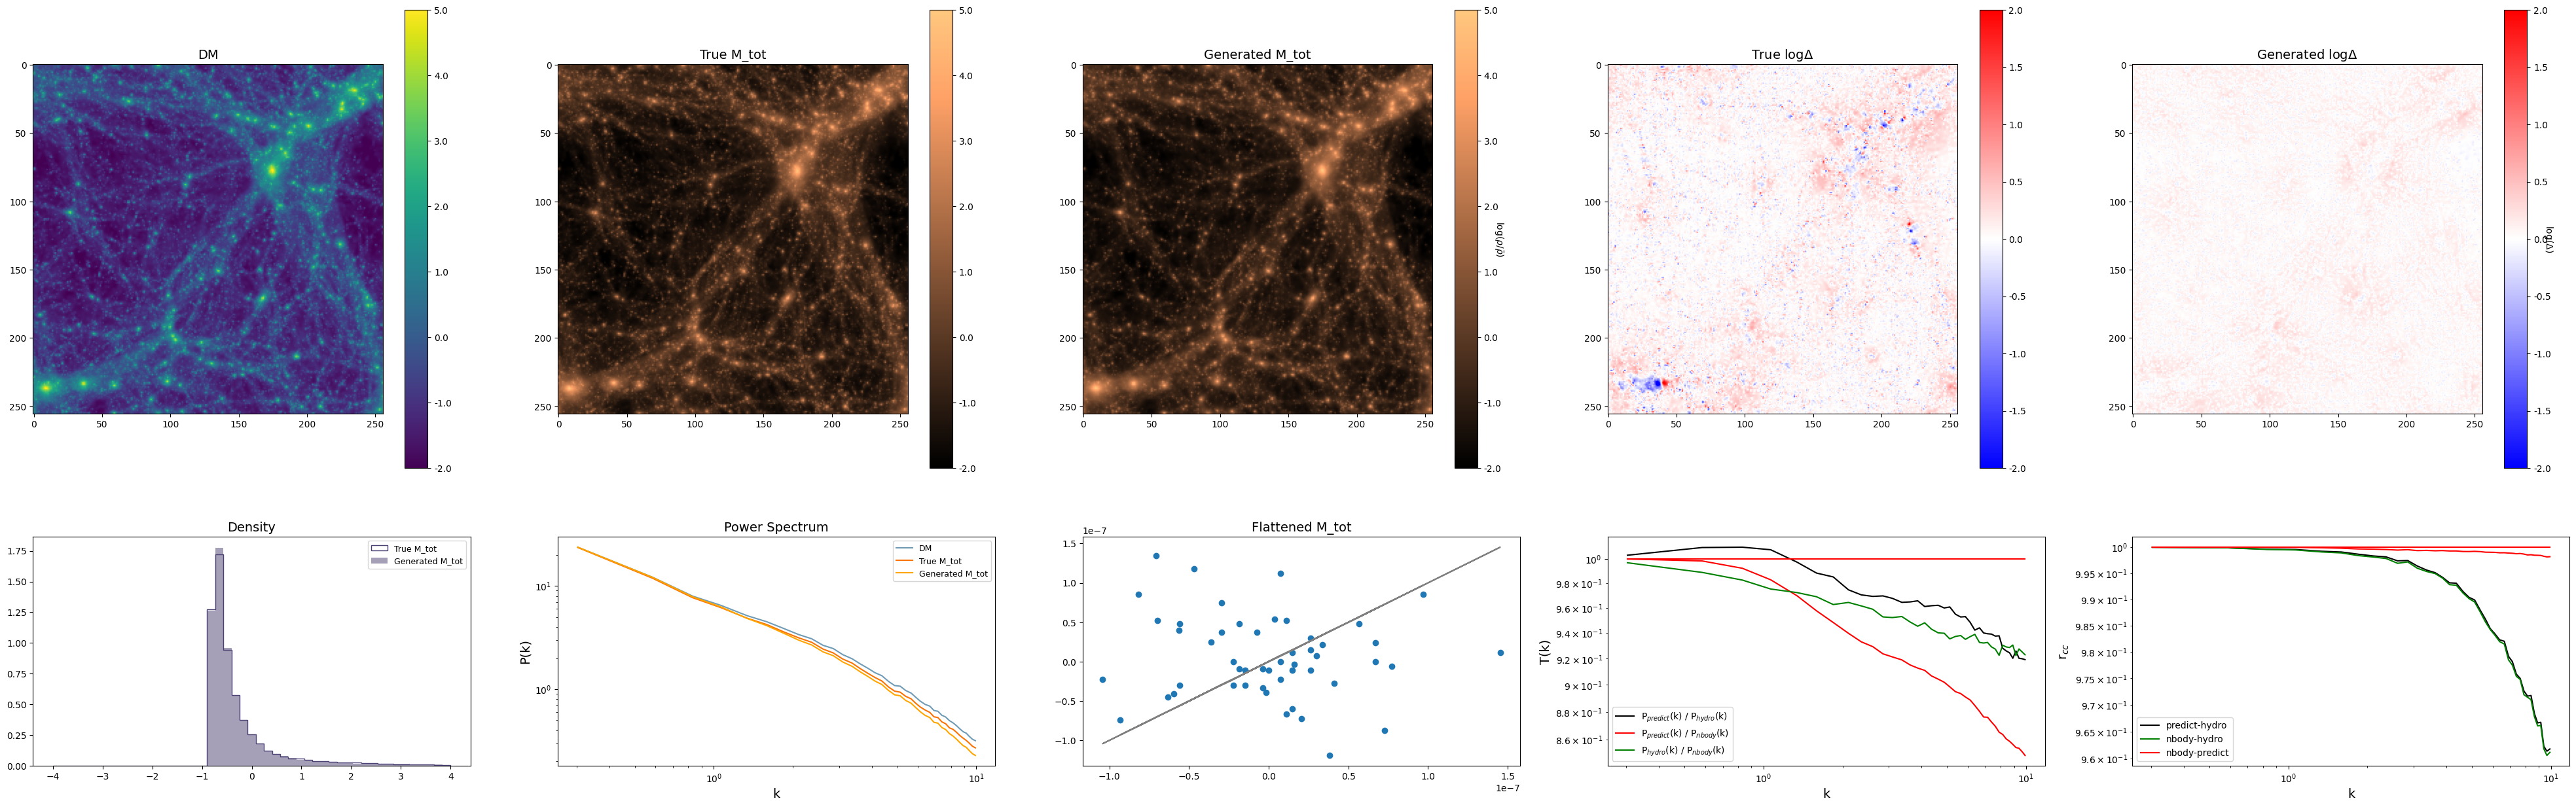

Testing DataLoader 0: 100%|██████████| 6/6 [00:10<00:00,  0.55it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       fourier_loss        │    0.16116034984588623    │
│          l1_loss          │    0.16736289858818054    │
│         test_loss         │            0.0            │
└───────────────────────────┴───────────────────────────┘

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml ExistingExperiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : UNet_Film_Moving_highk_Fourier_ONLY_weight_1e5_10_Butterworth_high_pass_lr_1e3_adamw_1e2_25_thickness_Nbody
COMET INFO:     url                   : https://www.comet.com/klinjin/nbody-hydro/0e88adc4347d42b281b021c9810e23ed
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     fourier_loss  : 0.16116034984588623
COMET INFO:     l1_loss       : 0.16736289858818054
COMET INFO:     test_loss [2] : (0.0, 0.3117828965187073)
COMET INFO:   Others:
COMET INFO:     Created from : pytorch-lightning
COMET INFO:     Name         : UNet_Film_Moving_highk_Fourier_ONLY_weight_1e5_10_Butterworth_high_pass_lr_1e3_adamw_1e2_25_thickness_Nbody
COMET INFO:  

In [14]:
#model = None: directly load from ckpt
test_loss = trainer.test(model=None, datamodule=dm_25_thick, ckpt_path = path)

## Conditional CNN + Fourier Loss + TF: m_cdm -> m_tot-m_cdm_tf (3D->2D: 25 thickness)

In [ ]:
dm_TF = get_astro_data_2D_from_3D(
        dataset,
        num_workers=num_workers,
        resize=cropsize,
        batch_size=batch_size)

In [15]:
print(len(dm_TF.train_data), len(dm_TF.valid_data),len(dm_TF.test_data))

2400 420 180


In [7]:
trainer.fit(model=cnn, datamodule=dm_TF) 

You are using a CUDA device ('NVIDIA A100-SXM4-80GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/klinjin/baryonize-dm/f22390c4a6594fc6812d7d1345119c55

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]

  | Name  | Type     | Params | Mode 
-------------------------------------------
0 | model | UNetFiLM | 44.2 M | train
-------------------------------------------
44.2 M    Trainable param

Sanity Checking: |          | 0/? [00:00<?, ?it/s]


Detected KeyboardInterrupt, attempting graceful shutdown ...
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Unet_Film_L1_epoch10_Fourier_weight_1e-5_1_10_Butterworth_high_pass_lr_1e-3_adamw_1e-2_25_thickness
COMET INFO:     url                   : https://www.comet.com/klinjin/baryonize-dm/f22390c4a6594fc6812d7d1345119c55
COMET INFO:   Others:
COMET INFO:     Created from : pytorch-lightning
COMET INFO:     Name         : Unet_Film_L1_epoch10_Fourier_weight_1e-5_1_10_Butterworth_high_pass_lr_1e-3_adamw_1e-2_25_thickness
COMET INFO:   Parameters:
COMET INFO:     dataset                : Astrid
COMET INFO:     fourier_upweight_range : (1, 10)
COMET INFO:     fourier_weight         : 1e-05
COMET IN

NameError: name 'exit' is not defined

In [13]:
path = trainer.checkpoint_callback.best_model_path 
print(path)

/pscratch/sd/l/lindajin/LOGS/Nbody_Hydro/b7e663e255bf4e649cee1e66666e2f12/checkpoints/latest-epoch=9-step=1750.ckpt


In [8]:
path_UNet_Film_10_epochs_ONLY_fourier_loss_3_10_zeros_elsewhere_25_thick = '/pscratch/sd/l/lindajin/LOGS/baryonize_DM/5ef90d60aaca4012837cd4275273e171/checkpoints/latest-epoch=9-step=1750.ckpt'
path_UNet_Film_10_epochs_ONLY_l1_loss_25_thick = '/pscratch/sd/l/lindajin/LOGS/baryonize_DM/62ce892d8ce84414ad1d864f0b3c09a3/checkpoints/latest-epoch=9-step=1750.ckpt'

## test if CNN_apply is correct --> ✅

In [70]:
test_predictions_ONLY_fourier_loss = trainer.predict(model=cnn, dataloaders=dm_25_thick.train_dataloader(), ckpt_path = path_UNet_Film_10_epochs_ONLY_fourier_loss_3_10_zeros_elsewhere_25_thick)

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/klinjin/baryonize-dm/96071eeeabd64a0da32d6e71b78e41a9

Restoring states from the checkpoint path at /pscratch/sd/l/lindajin/LOGS/baryonize_DM/5ef90d60aaca4012837cd4275273e171/checkpoints/latest-epoch=9-step=1750.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
COMET WARNING: String value length exceeds 1000 characters and will be truncated. Provided value: 'UNetFiLM(
  (inc): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, padding_mode=circular)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=Tru

Predicting DataLoader 0: 100%|██████████| 175/175 [00:05<00:00, 29.50it/s]


COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml ExistingExperiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Unet_new_Film_Fourier_L1_weight_1e-4_2_20_high_pass_lr_5e-3_25_thickness
COMET INFO:     url                   : https://www.comet.com/klinjin/baryonize-dm/96071eeeabd64a0da32d6e71b78e41a9
COMET INFO:   Others:
COMET INFO:     Created from : pytorch-lightning
COMET INFO:     Name         : Unet_new_Film_Fourier_L1_weight_1e-4_2_20_high_pass_lr_5e-3_25_thickness
COMET INFO:   Parameters:
COMET INFO:     dataset          : Astrid
COMET INFO:     image_shape      : (1, 256, 256)
COMET INFO:     learning_rate    : 0.005
COMET INFO:     model            : UNetFiLM(
  (inc): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(1, 64, kernel

In [72]:
test_predictions_ONLY_fourier_loss = np.array(test_predictions_ONLY_fourier_loss).reshape([2100,256,256]) #path_UNet_Film_50_epochs_fourier_loss_2_10

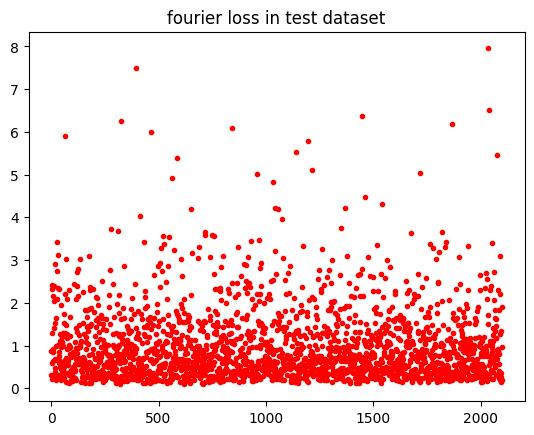

In [86]:
test_target = []
for t in dm_25_thick.train_data:
    test_target.append(t[2])
    
test_predictions_ONLY_fourier_loss_ = Tensor(np.array(test_predictions_ONLY_fourier_loss)).unsqueeze(1)
test_predictions_ = Tensor(test_predictions).unsqueeze(1)

plt.figure()
for i in np.arange(len(test_predictions)):                
    loss = cnn.fourier_loss(test_predictions_ONLY_fourier_loss_[i].unsqueeze(0), test_target[i])
    plt.plot(i, loss, '.', c='r')
plt.title('fourier loss in test dataset')
plt.show()

In [84]:
print(len(test_target))

2100


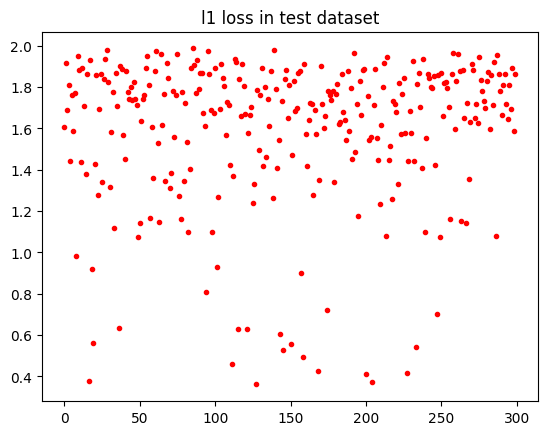

In [44]:
plt.figure()
for i in np.arange(len(test_predictions)):                
    loss =  l1_loss(test_predictions_[i].unsqueeze(0), test_targets_[i])
    plt.plot(i, loss, '.', c='r')
plt.title('l1 loss in test dataset')
plt.show()

In [75]:
test_predictions = trainer.predict(model=cnn, dataloaders=dm_25_thick.train_dataloader(), ckpt_path = path_UNet_Film_10_epochs_ONLY_l1_loss_25_thick)

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/klinjin/baryonize-dm/96071eeeabd64a0da32d6e71b78e41a9

Restoring states from the checkpoint path at /pscratch/sd/l/lindajin/LOGS/baryonize_DM/62ce892d8ce84414ad1d864f0b3c09a3/checkpoints/latest-epoch=9-step=1750.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
COMET WARNING: String value length exceeds 1000 characters and will be truncated. Provided value: 'UNetFiLM(
  (inc): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, padding_mode=circular)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=Tru

Predicting DataLoader 0: 100%|██████████| 175/175 [00:05<00:00, 29.36it/s]


COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml ExistingExperiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Unet_new_Film_Fourier_L1_weight_1e-4_2_20_high_pass_lr_5e-3_25_thickness
COMET INFO:     url                   : https://www.comet.com/klinjin/baryonize-dm/96071eeeabd64a0da32d6e71b78e41a9
COMET INFO:   Others:
COMET INFO:     Created from : pytorch-lightning
COMET INFO:     Name         : Unet_new_Film_Fourier_L1_weight_1e-4_2_20_high_pass_lr_5e-3_25_thickness
COMET INFO:   Parameters:
COMET INFO:     dataset          : Astrid
COMET INFO:     image_shape      : (1, 256, 256)
COMET INFO:     learning_rate    : 0.005
COMET INFO:     model            : UNetFiLM(
  (inc): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(1, 64, kernel

train on L1 only


/tmp/ipykernel_1997182/3169583532.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  test_predictions = Tensor(np.array(test_predictions).reshape([2100,1,256,256]))


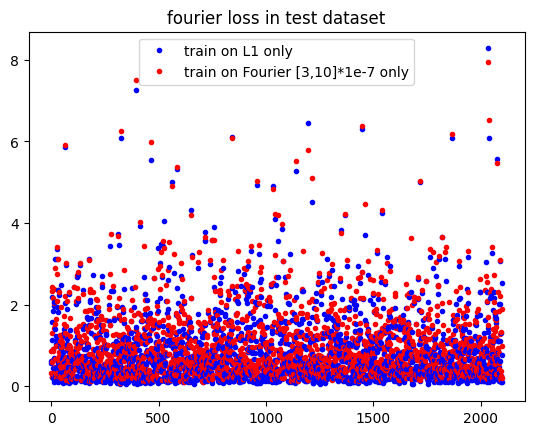

/tmp/ipykernel_1997182/3169583532.py:23: UserWarning: Using a target size (torch.Size([1, 256, 256])) that is different to the input size (torch.Size([1, 1, 256, 256])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss =  l1_loss(test_predictions[i].unsqueeze(0), test_target[i])
/tmp/ipykernel_1997182/3169583532.py:28: UserWarning: Using a target size (torch.Size([1, 256, 256])) that is different to the input size (torch.Size([1, 1, 256, 256])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = l1_loss(test_predictions_ONLY_fourier_loss_[i].unsqueeze(0), test_target[i])


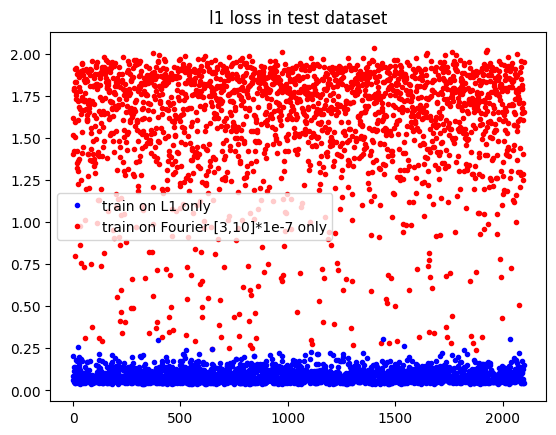

In [87]:
print('train on L1 only')

test_predictions = Tensor(np.array(test_predictions).reshape([2100,1,256,256]))

plt.figure()
for i in np.arange(len(test_predictions)):                
    loss = cnn.fourier_loss(test_predictions[i].unsqueeze(0), test_target[i])
    if i == 0:
        plt.plot(i, loss, '.', c='b', label = 'train on L1 only')
    else:
        plt.plot(i, loss, '.', c='b')
    loss = cnn.fourier_loss(test_predictions_ONLY_fourier_loss_[i].unsqueeze(0), test_target[i])
    if i == 0:
        plt.plot(i, loss, '.', c='r', label = 'train on Fourier [3,10]*1e-7 only')
    else:
        plt.plot(i, loss, '.', c='r')
plt.title('fourier loss in test dataset')
plt.legend()
plt.show()

plt.figure()
for i in np.arange(len(test_predictions)):                
    loss =  l1_loss(test_predictions[i].unsqueeze(0), test_target[i])
    if i == 0:
        plt.plot(i, loss, '.', c='b', label = 'train on L1 only')
    else:
        plt.plot(i, loss, '.', c='b')
    loss = l1_loss(test_predictions_ONLY_fourier_loss_[i].unsqueeze(0), test_target[i])
    if i == 0:
        plt.plot(i, loss, '.', c='r', label = 'train on Fourier [3,10]*1e-7 only')
    else:
        plt.plot(i, loss, '.', c='r')
plt.title('l1 loss in test dataset')
plt.legend()
plt.show()